In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import expm
from scipy.sparse.linalg import eigsh
from tqdm import tqdm
import mosek

from quspin.operators import hamiltonian
from quspin.basis import spinful_fermion_basis_1d

import random
from sympy import Matrix
import cvxpy as cp

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],   # default LaTeX font
    "text.latex.preamble": r"\usepackage{amsmath}",
    "font.size": 15, 
})

In [4]:
def one_dim_chain_row_labels(I,L):
    rows  = np.zeros(shape = (I,L) , dtype=np.float64)
    
    for i in range(I):
        for j in range(L):
            if rows[i][i+j] == 0 and rows[i][i+j+1] == 0:
                rows[i][i+j] = 1
                rows[i][i+j+1] = 2
            else:
                break
    return rows


def tritarray(x,M):
    tritarray = np.zeros(shape = M)
    for j in range(M):
        r = x % 3
        x = x // 3 
        tritarray[-(j+1)] = r
    return tritarray

def random_pulses(M,K):
    
    N = 3**M
    
    sample = random.sample(range(N),K) 
    pulses = np.zeros(shape = (K,M)) # K pulses of length M
    
    for j in range(K):
        pulses[j] = tritarray(sample[j],M)
        
    return pulses

def all_pulses(M):
    N = 3**M
    
    pulses = np.zeros(shape= (N,M))
    
    for j in range(N):
        pulses[j] = tritarray(j,M)
        
    return pulses

def check_feasible(F):

    x = cp.Variable(F.shape[1])
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == 0, x >= 1]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    LP_has_solution = 0
    F_has_full_rank = 0
    
    if type(x.value) == np.ndarray:
        LP_has_solution = 1
    if F.shape[0]- np.linalg.matrix_rank(F)==0:
        F_has_full_rank = 1
    feasible = LP_has_solution * F_has_full_rank
    
    return bool(feasible)

def constraint_matrix_given_pulses(L,K,rows,pulses):

    I = int((L-1)) 
    R = I
    F = np.zeros(shape = (R,K), dtype=np.complex128)
    w = np.exp(1j*2*np.pi/3)

    for i in range(R):
        for j in range(K):
            power = rows[i]@pulses[j]
            F[i][j] = w**power

    return F

def constraint_matrix_all(L):
    pulses = all_pulses(L)
    N = 3**L
    R = L-1
    F = np.zeros(shape = (R,N), dtype=np.complex128)
    w = np.exp(1j*2*np.pi/3)
    
    rows = one_dim_chain_row_labels(R,L)
    
    for i in range(R):
        for j in range(N):
            power = rows[i]@pulses[j]
            F[i][j] = w**power
            
    return F
    
    

def hamiltonian_engineering(L,K,rows,pulses,beta):

    F = constraint_matrix_given_pulses(L,K,rows,pulses)
    
    # print(check_feasible(F))

    x = cp.Variable(K)
    objective = cp.Minimize(cp.sum(x))
    constraints = [F @ x == beta, x>=0]

    # Define and solve the problem
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)

    # # Print solution
    # print("Optimal value:", problem.value)
    # print("Optimal x:", x.value)
    
    return problem.value, x.value, check_feasible(F)

def hamiltonian_engineering_all_pulses(L,beta):
    
    N = 3**L
    F_all = constraint_matrix_all(L)
    x = cp.Variable(N)
    objective = cp.Minimize(cp.sum(x))
    constraints = [F_all @ x == beta, x>=0]
    
    problem = cp.Problem(objective, constraints)
    problem.solve(solver = cp.MOSEK)
    
    return problem.value, x.value, check_feasible(F_all)

def random_hamiltonian_coef(R, magnitude=10):
    # uniform angle
    theta = 2 * np.pi * np.random.rand(R)
    # radius distributed as sqrt of uniform to get uniform area measure
    r = magnitude * np.sqrt(np.random.rand(R))
    return r * np.exp(1j * theta)

In [20]:
def delta_times(L = 10 , shots = 50):
    ratios = np.arange(6,20,1,dtype=int)

    R = L-1
    rows = one_dim_chain_row_labels(R,L)

    q_times = [[] for _ in range(len(ratios))]
    opt_times = [[] for _ in range(len(ratios))]
    delta_times = [[] for _ in range(len(ratios))]
    all_pulses0 = all_pulses(L)

    for j in tqdm(range(len(ratios))):
        x = 0
        while x<shots:
            K = ratios[j]*R
            
            pulses = random_pulses(L,K)
            
            F = constraint_matrix_given_pulses(L,K,rows,pulses)
            feasible = check_feasible(F)
            
            if feasible ==True:
                beta = random_hamiltonian_coef(L-1)
                q_time = hamiltonian_engineering(L,K,rows,pulses,beta)[0]
                opt_time = hamiltonian_engineering_all_pulses(L,beta)[0]
                delta = q_time - opt_time
                q_times[j].append(q_time)
                opt_times[j].append(opt_time)
                delta_times[j].append(delta)

            x += 1
        q_times[j] = np.array(q_times[j])
    return q_times, opt_times, delta_times

In [21]:
qtimes,opttimes,deltatimes = delta_times()

  0%|          | 0/14 [00:00<?, ?it/s]

In [23]:
for j in range(len(deltatimes)):
    deltatimes[j] = np.array(deltatimes[j])

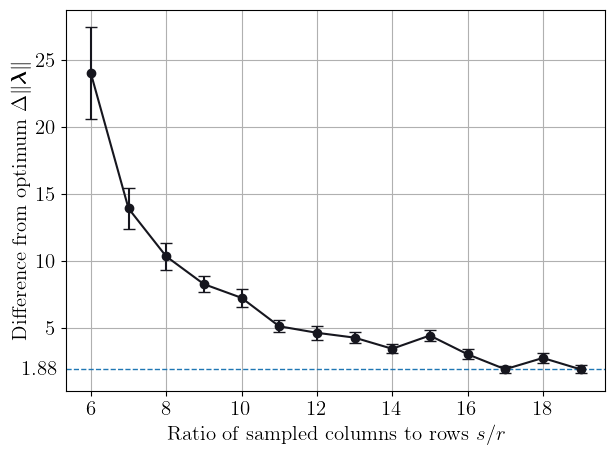

In [ ]:
deltameans = [x.mean() for x in deltatimes]
stdmeans = [x.std(ddof=1) for x in deltatimes]
semmeans = stdmeans/ np.sqrt(np.array([len(x) for x in deltatimes]))
ratios = np.arange(6,20,1,dtype=int)

cmap = plt.get_cmap("bone")
colors = cmap(np.linspace(0.6, 0.1, 4)) 

plt.figure()

y0 = deltameans[-1]
plt.axhline(y=y0, linestyle='--', linewidth=1)

ax = plt.gca()
ax.annotate(f"{y0:.3g}",
            xy=(0, y0), xycoords=('axes fraction', 'data'),
            xytext=(-6, 0), textcoords='offset points',
            ha='right', va='center')
plt.errorbar(ratios, deltameans, yerr = semmeans,fmt='o-', color = colors[3], capsize=4)
# plt.axhline(y=deltameans[-1], linestyle='--', linewidth=1,label = deltameans[-1])
plt.xlabel(r"Ratio of sampled columns to rows $s/r$")
plt.ylabel(r"Difference from optimum $\Delta\|\boldsymbol{\lambda}\|_1$")
plt.tight_layout()
plt.grid()
plt.savefig("relax_vs_optimal.pdf",bbox_inches = 'tight', dpi =300, format ='pdf')
plt.show()